# Xây dựng và đánh giá mô hình dự báo nhu cầu thuê xe

Đơn vị quan sát là một giờ; biến cần dự đoán là `Rented Bike Count`. Chỉ dùng các giờ có `Functioning Day = Yes`, giống phạm vi của notebook phân tích thăm dò. Hai mô hình cần so sánh theo yêu cầu báo cáo là hồi quy tuyến tính và hồi quy đa thức bậc 2. Mốc dự đoán bằng trung bình giúp kiểm tra mô hình có tốt hơn cách dự đoán đơn giản hay không.

Tập kiểm tra là các ngày cuối của chuỗi thời gian. Thời tiết của giờ cần dự đoán được giả định là đã biết hoặc có dự báo tương ứng; đây là dự đoán có điều kiện theo thời tiết, không phải dự báo thời tiết.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, RobustScaler

sns.set_theme(style="whitegrid")

ModuleNotFoundError: No module named 'sklearn'

## 1. Đọc dữ liệu và xác định phạm vi

Không dùng `Date` thô hoặc biến mục tiêu làm đầu vào. `Functioning Day` chỉ dùng để lọc phạm vi; mô hình chỉ áp dụng cho giờ hệ thống hoạt động.

In [ ]:
project_root = Path.cwd()
if not (project_root / "data" / "SeoulBikeData.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "SeoulBikeData.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu: {data_path}")

raw = pd.read_csv(data_path, encoding="utf-8-sig")
raw["Date"] = pd.to_datetime(raw["Date"], format="%d/%m/%Y")
df = (
    raw.loc[raw["Functioning Day"].eq("Yes")]
    .copy()
    .sort_values(["Date", "Hour"])
    .reset_index(drop=True)
)
df["Day of Week"] = df["Date"].dt.dayofweek

print(f"Dữ liệu gốc: {len(raw):,} giờ; sau lọc: {len(df):,} giờ.")
print(f"Khoảng thời gian: {df['Date'].min():%d/%m/%Y} đến {df['Date'].max():%d/%m/%Y}.")
print(f"Giá trị thiếu: {df.isna().sum().sum():,}; trùng ngày-giờ: {df.duplicated(['Date', 'Hour']).sum():,}.")

Dữ liệu gốc: 8,760 giờ; sau lọc: 8,465 giờ.
Khoảng thời gian: 01/12/2017 đến 30/11/2018.
Giá trị thiếu: 0; trùng ngày-giờ: 0.


## 2. Chia dữ liệu theo ngày và chọn biến

Các ngày được sắp theo thời gian: 70% đầu để huấn luyện, 15% tiếp theo để chọn mô hình, 15% cuối để kiểm tra một lần sau khi chọn. Cách chia theo **ngày** giữ các giờ của cùng một ngày trong cùng một tập và phản ánh bài toán dự đoán giai đoạn đến sau. Một năm dữ liệu có thể gây khác biệt mùa giữa các tập; kết quả cần được đọc trong giới hạn này.

Biến thời gian: giờ, thứ trong tuần, mùa, ngày lễ. Biến thời tiết: nhiệt độ, độ ẩm, tốc độ gió, mưa, bức xạ mặt trời. Không dùng nhiệt độ điểm sương đồng thời với nhiệt độ vì hai biến liên hệ rất mạnh trong EDA.

In [3]:
categorical_features = ["Hour", "Day of Week", "Seasons", "Holiday"]
numeric_features = [
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Rainfall(mm)",
    "Solar Radiation (MJ/m2)",
]
feature_columns = categorical_features + numeric_features
target_column = "Rented Bike Count"

days = np.sort(df["Date"].unique())
train_end = int(len(days) * 0.70)
validation_end = int(len(days) * 0.85)
train_days, validation_days, test_days = (
    days[:train_end], days[train_end:validation_end], days[validation_end:]
)
train = df.loc[df["Date"].isin(train_days)].copy()
validation = df.loc[df["Date"].isin(validation_days)].copy()
test = df.loc[df["Date"].isin(test_days)].copy()

split_summary = pd.DataFrame(
    [
        {"Tập": name, "Số ngày": part["Date"].nunique(), "Số giờ": len(part),
         "Từ ngày": part["Date"].min().date(), "Đến ngày": part["Date"].max().date()}
        for name, part in [("Huấn luyện", train), ("Chọn mô hình", validation), ("Kiểm tra", test)]
    ]
)
display(split_summary)
season_split = pd.concat([
    part[["Seasons"]].assign(Tập=name)
    for name, part in [("Huấn luyện", train), ("Chọn mô hình", validation), ("Kiểm tra", test)]
])
display(pd.crosstab(season_split["Tập"], season_split["Seasons"]))

,Tập,Số ngày,Số giờ,Từ ngày,Đến ngày
0,Huấn luyện,247,5928,2017-12-01,2018-08-06
1,Chọn mô hình,53,1272,2018-08-07,2018-10-03
2,Kiểm tra,53,1265,2018-10-05,2018-11-30


Seasons,Autumn,Spring,Summer,Winter
Tập,,,,
Chọn mô hình,672,0,600,0
Huấn luyện,0,2160,1608,2160
Kiểm tra,1265,0,0,0


## 3. Kiểm tra ngoại lệ

Quy tắc 1,5 × IQR chỉ đánh dấu quan sát nằm xa phần giữa của phân phối. Các đỉnh nhu cầu thuê và các giờ thời tiết cực đoan có thể là dữ liệu thật, nên không xóa hoặc cắt ngưỡng theo biến mục tiêu. Đặc biệt, lượng mưa có quá nhiều giá trị 0 nên IQR bằng 0; khi đó các giờ có mưa đều bị đánh dấu, nhưng không phải lỗi dữ liệu. `RobustScaler` dùng trung vị và IQR của **tập huấn luyện** để giảm ảnh hưởng của ngoại lệ lên thang đo biến đầu vào. Bước này được đặt trong pipeline để tránh học thông tin từ tập sau.

In [4]:
outlier_rows = []
for column in [target_column] + numeric_features:
    q1, q3 = train[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rows.append({
        "Biến": column,
        "Ngoài hàng rào IQR (tập huấn luyện)": int(((train[column] < lower) | (train[column] > upper)).sum()),
        "Ngưỡng dưới": lower,
        "Ngưỡng trên": upper,
    })
display(pd.DataFrame(outlier_rows))

,Biến,Ngoài hàng rào IQR (tập huấn luyện),Ngưỡng dưới,Ngưỡng trên
0,Rented Bike Count,232,-1014.50,2167.50
1,Temperature(°C),0,-31.80,53.80
2,Humidity(%),0,-7.00,121.00
3,Wind speed (m/s),58,-1.25,4.75
4,Rainfall(mm),354,0.00,0.00
5,Solar Radiation (MJ/m2),479,-1.38,2.30


## 4. Pipeline và các mô hình

Hồi quy tuyến tính là mô hình chính, dễ giải thích. Mô hình đa thức bậc 2 chỉ thêm bình phương nhiệt độ, bình phương độ ẩm và tương tác của hai biến này; các biến khác giữ nguyên. Cả hai dùng cùng các tập dữ liệu. One-hot encoding dùng `drop='first'` để tránh cột giả dư thừa; các biến số thiếu (nếu có khi tái sử dụng notebook) được điền bằng trung vị của tập huấn luyện.

In [5]:
def numeric_pipeline(polynomial=False):
    steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()),
    ]
    if polynomial:
        steps.append(("polynomial", PolynomialFeatures(degree=2, include_bias=False)))
    return Pipeline(steps)


def categorical_pipeline():
    return Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ])


linear_preprocess = ColumnTransformer([
    ("weather", numeric_pipeline(), numeric_features),
    ("calendar", categorical_pipeline(), categorical_features),
])

polynomial_features = ["Temperature(°C)", "Humidity(%)"]
other_numeric_features = [column for column in numeric_features if column not in polynomial_features]
polynomial_preprocess = ColumnTransformer([
    ("curved_weather", numeric_pipeline(polynomial=True), polynomial_features),
    ("other_weather", numeric_pipeline(), other_numeric_features),
    ("calendar", categorical_pipeline(), categorical_features),
])

models = {
    "Mốc trung bình": DummyRegressor(strategy="mean"),
    "Hồi quy tuyến tính": Pipeline([
        ("preprocess", linear_preprocess),
        ("regression", LinearRegression()),
    ]),
    "Hồi quy đa thức bậc 2": Pipeline([
        ("preprocess", polynomial_preprocess),
        ("regression", LinearRegression()),
    ]),
}

## 5. Chọn mô hình trên tập kiểm định

MSE là tiêu chí chọn chính; RMSE đổi sai số về đơn vị lượt thuê/giờ; R² so sánh với dự đoán trung bình. Tập kiểm tra cuối chưa được dùng ở bước này.

In [1]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }


validation_scores = {}
for name, model in models.items():
    fitted = clone(model).fit(train[feature_columns], train[target_column])
    prediction = fitted.predict(validation[feature_columns])
    validation_scores[name] = evaluate(validation[target_column], prediction)

validation_table = pd.DataFrame.from_dict(validation_scores, orient="index").sort_values("MSE")
display(validation_table.round(3))
candidate_names = ["Hồi quy tuyến tính", "Hồi quy đa thức bậc 2"]
selected_name = min(candidate_names, key=lambda name: validation_scores[name]["MSE"])
print(f"Mô hình được chọn theo MSE kiểm định: {selected_name}")

NameError: name 'models' is not defined

## 6. Đánh giá cuối trên giai đoạn đến sau

Sau khi chọn mô hình, huấn luyện lại mỗi mô hình trên dữ liệu huấn luyện và kiểm định gộp. Bảng kiểm tra cuối trình bày minh bạch cả hai ứng viên và mốc trung bình; quyết định chọn mô hình vẫn dựa trên tập kiểm định ở phần trên.

In [7]:
train_validation = pd.concat([train, validation], ignore_index=True)
fitted_models = {}
test_predictions = {}
test_scores = {}
for name, model in models.items():
    fitted_models[name] = clone(model).fit(
        train_validation[feature_columns], train_validation[target_column]
    )
    test_predictions[name] = fitted_models[name].predict(test[feature_columns])
    test_scores[name] = evaluate(test[target_column], test_predictions[name])

test_table = pd.DataFrame.from_dict(test_scores, orient="index").sort_values("MSE")
display(test_table.round(3))
print(f"Mô hình đã chọn từ tập kiểm định: {selected_name}")

,MSE,RMSE,MAE,R²
Hồi quy tuyến tính,99663.511,315.695,229.748,0.673
Hồi quy đa thức bậc 2,100114.194,316.408,242.385,0.671
Mốc trung bình,320345.381,565.991,442.864,-0.052


Mô hình đã chọn từ tập kiểm định: Hồi quy đa thức bậc 2


## 7. Kiểm tra sai số và phân phối dự đoán

Đồ thị được tạo từ **mô hình đã chọn**, không chọn lại bằng hình dạng đồ thị của tập kiểm tra. Đường chéo ở hình 6.1 là dự đoán hoàn hảo; đường ngang 0 ở hình 6.2 là sai số bằng 0. Sai số của dữ liệu theo giờ có thể phụ thuộc thời gian, vì vậy biểu đồ không tự chứng minh các giả định thống kê độc lập.

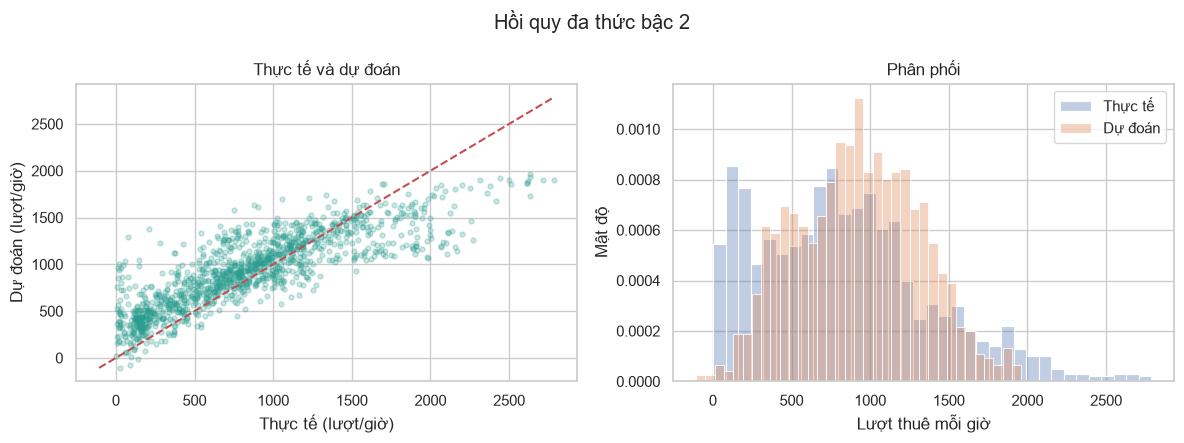

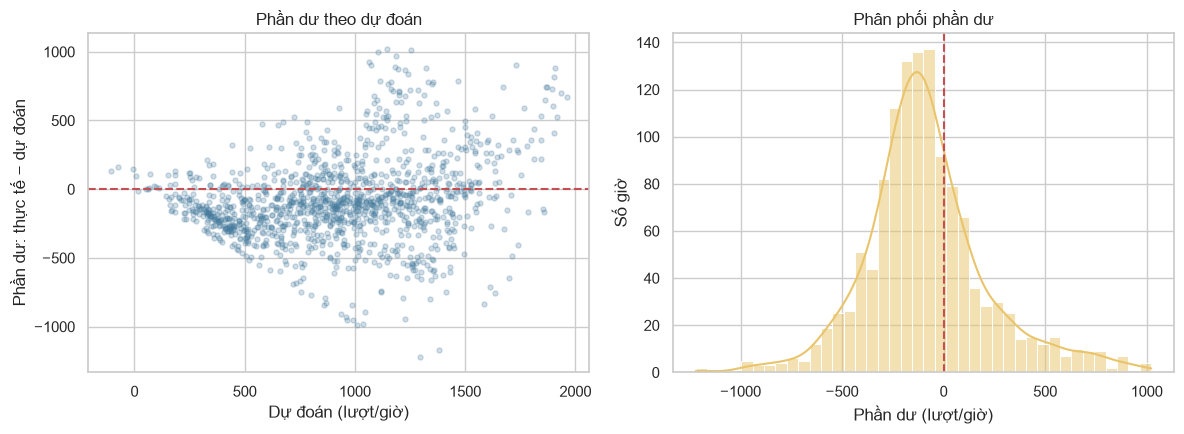

In [8]:
actual = test[target_column].to_numpy()
predicted = test_predictions[selected_name]
residual = actual - predicted
figure_dir = project_root / "noi-dung-bao-cao" / "bao-cao" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(actual, predicted, alpha=0.25, s=13, color="#2A9D8F")
low = min(actual.min(), predicted.min())
high = max(actual.max(), predicted.max())
axes[0].plot([low, high], [low, high], color="#C44E52", linestyle="--")
axes[0].set(xlabel="Thực tế (lượt/giờ)", ylabel="Dự đoán (lượt/giờ)", title="Thực tế và dự đoán")
sns.histplot(actual, bins=35, stat="density", alpha=0.35, label="Thực tế", ax=axes[1])
sns.histplot(predicted, bins=35, stat="density", alpha=0.35, label="Dự đoán", ax=axes[1])
axes[1].set(xlabel="Lượt thuê mỗi giờ", ylabel="Mật độ", title="Phân phối")
axes[1].legend()
fig.suptitle(selected_name)
fig.tight_layout()
fig.savefig(figure_dir / "chuong-6-thuc-te-du-doan.png", dpi=170, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(predicted, residual, alpha=0.25, s=13, color="#457B9D")
axes[0].axhline(0, color="#C44E52", linestyle="--")
axes[0].set(xlabel="Dự đoán (lượt/giờ)", ylabel="Phần dư: thực tế − dự đoán", title="Phần dư theo dự đoán")
sns.histplot(residual, bins=40, kde=True, ax=axes[1], color="#E9C46A")
axes[1].axvline(0, color="#C44E52", linestyle="--")
axes[1].set(xlabel="Phần dư (lượt/giờ)", ylabel="Số giờ", title="Phân phối phần dư")
fig.tight_layout()
fig.savefig(figure_dir / "chuong-6-phan-du.png", dpi=170, bbox_inches="tight")
plt.show()

In [9]:
diagnostics = test[["Date", "Hour", "Seasons", target_column]].copy()
diagnostics["Dự đoán"] = predicted
diagnostics["Sai số tuyệt đối"] = np.abs(residual)
diagnostics["Phần dư"] = residual
hourly_error = diagnostics.groupby("Hour")["Sai số tuyệt đối"].agg(["count", "mean"]).rename(
    columns={"count": "Số giờ", "mean": "MAE"}
)
display(hourly_error.round(2))
print(f"Số dự đoán âm: {(predicted < 0).sum():,}/{len(predicted):,}")

,Số giờ,MAE
Hour,,
0,52,223.63
1,52,229.29
2,52,222.04
3,52,214.76
4,52,215.41
5,52,208.13
6,52,171.20
7,53,296.61
8,53,634.63


Số dự đoán âm: 3/1,265


## 8. Giới hạn diễn giải

Dữ liệu chỉ bao phủ một năm và tập kiểm tra là giai đoạn cuối năm, nên kết quả chưa chứng minh mô hình ổn định qua nhiều năm. Mô hình dùng thời tiết của chính giờ được dự đoán; khi áp dụng trước thời điểm đó, cần đưa vào dự báo thời tiết tương ứng. Các hệ số và biểu đồ không chứng minh quan hệ nhân quả.